# Cafe Sales Analysis 📊

**Author:** Ceren Benzer
**Dataset:** 7,392 transactions across 90 days (Jan – Mar 2024)
**Goal:** Identify revenue drivers and operational opportunities for a small cafe.

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Quality Check](#2)
3. [Product Performance](#3)
4. [Peak Hour Analysis](#4)
5. [Weekday vs Weekend](#5)
6. [Hour × Day Heatmap](#6)
7. [Payment Method Insights](#7)
8. [Key Findings & Recommendations](#8)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

PALETTE = {
    "primary":   "#2E5266",
    "secondary": "#6E8898",
    "accent":    "#E2C044",
    "highlight": "#D7263D",
}

df = pd.read_csv("../data/cafe_sales.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,transaction_id,date,day_of_week,hour,product,category,quantity,unit_price,total,payment_method
0,TX00001,2024-01-01,Monday,19,Cheesecake,Dessert,1,140,140,Card
1,TX00002,2024-01-01,Monday,8,Croissant,Pastry,1,75,75,Cash
2,TX00003,2024-01-01,Monday,8,Sandwich,Food,2,130,260,Card
3,TX00004,2024-01-01,Monday,10,Latte,Coffee,1,95,95,Card
4,TX00005,2024-01-01,Monday,13,Cappuccino,Coffee,1,90,90,Card


## 2. Data Quality Check <a id='2'></a>

Before analysis, we verify there are no missing values, no duplicate transactions, and that data types are correct.

In [2]:
print(f"Shape         : {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum()}")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
df.dtypes

Shape         : (7392, 10)
Missing values: 0
Duplicates    : 0
Date range    : 2024-01-01 → 2024-03-30


transaction_id               str
date              datetime64[us]
day_of_week                  str
hour                       int64
product                      str
category                     str
quantity                   int64
unit_price                 int64
total                      int64
payment_method               str
dtype: object

In [3]:
df.describe()

,date,hour,quantity,unit_price,total
count,7392,7392.000000,7392.000000,7392.000000,7392.000000
mean,2024-02-15 04:57:16.363636,14.533685,1.269886,84.508929,107.222673
min,2024-01-01 00:00:00,8.000000,1.000000,35.000000,35.000000
25%,2024-01-23 00:00:00,10.000000,1.000000,65.000000,70.000000
50%,2024-02-16 00:00:00,14.000000,1.000000,75.000000,90.000000
75%,2024-03-09 00:00:00,19.000000,1.000000,110.000000,130.000000
max,2024-03-30 00:00:00,22.000000,3.000000,140.000000,420.000000
std,NaN,4.355058,0.502541,31.667493,60.299821


## 3. Product Performance <a id='3'></a>

Which products drive the most revenue? Are best-sellers by volume the same as by revenue?

In [4]:
product_perf = (
    df.groupby("product")
    .agg(revenue=("total", "sum"),
         units_sold=("quantity", "sum"),
         transactions=("transaction_id", "count"))
    .sort_values("revenue", ascending=False)
)
product_perf["revenue_share_%"] = (product_perf["revenue"] / product_perf["revenue"].sum() * 100).round(1)
product_perf

,revenue,units_sold,transactions,revenue_share_%
product,,,,
Sandwich,119080,916,717,15.0
Cheesecake,113540,811,643,14.3
Brownie,95260,866,673,12.0
Cappuccino,93780,1042,816,11.8
Latte,87115,917,741,11.0
Croissant,78900,1052,832,10.0
Filter Coffee,68600,980,779,8.7
Espresso,64155,987,773,8.1
Green Tea,38700,860,679,4.9


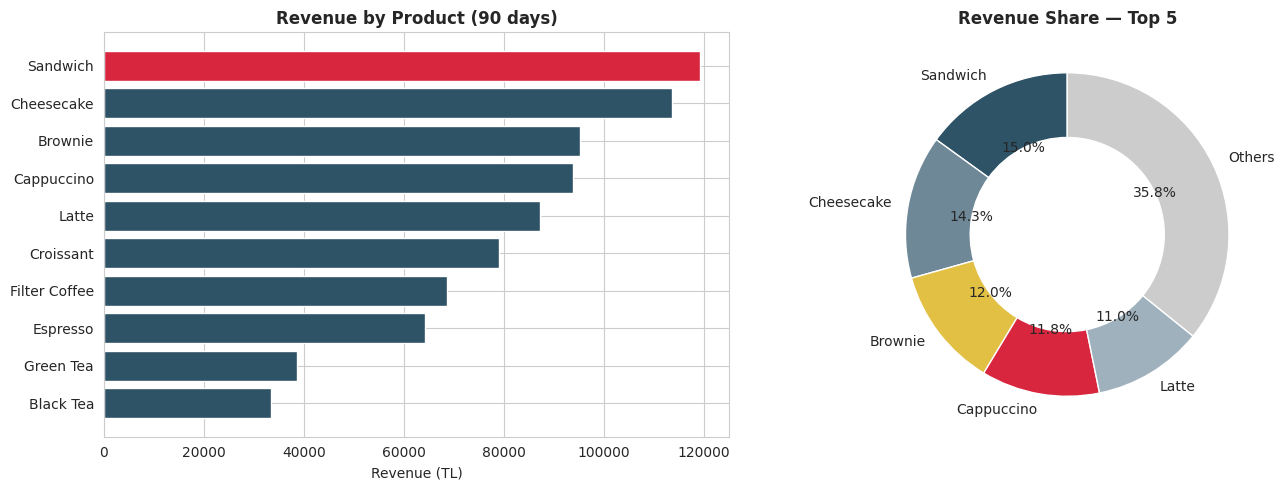

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

perf_sorted = product_perf.sort_values("revenue")
colors = [PALETTE["highlight"] if i == len(perf_sorted) - 1
          else PALETTE["primary"] for i in range(len(perf_sorted))]
axes[0].barh(perf_sorted.index, perf_sorted["revenue"], color=colors)
axes[0].set_title("Revenue by Product (90 days)", fontweight="bold")
axes[0].set_xlabel("Revenue (TL)")

top5 = product_perf.head(5)
others = product_perf["revenue"].iloc[5:].sum()
axes[1].pie(
    list(top5["revenue"]) + [others],
    labels=list(top5.index) + ["Others"],
    autopct="%1.1f%%", startangle=90,
    colors=[PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"],
            PALETTE["highlight"], "#9FB1BC", "#cccccc"],
    wedgeprops=dict(width=0.4, edgecolor="white"),
)
axes[1].set_title("Revenue Share — Top 5", fontweight="bold")
plt.tight_layout()
plt.show()

**Finding:** Sandwiches and Cheesecake are the top revenue generators, despite coffee dominating in transaction count. Higher unit prices on food items create a wider gap between volume leaders and revenue leaders.

## 4. Peak Hour Analysis <a id='4'></a>

When does the cafe make the most money? Knowing this informs staffing and stock decisions.

In [6]:
hourly = df.groupby("hour").agg(
    revenue=("total", "sum"),
    transactions=("transaction_id", "count")
).reset_index()

peak = hourly.loc[hourly["revenue"].idxmax()]
print(f"Peak hour: {peak['hour']}:00 — {peak['revenue']:,.0f} TL revenue, {peak['transactions']} transactions")

Peak hour: 19:00 — 94,965 TL revenue, 824 transactions


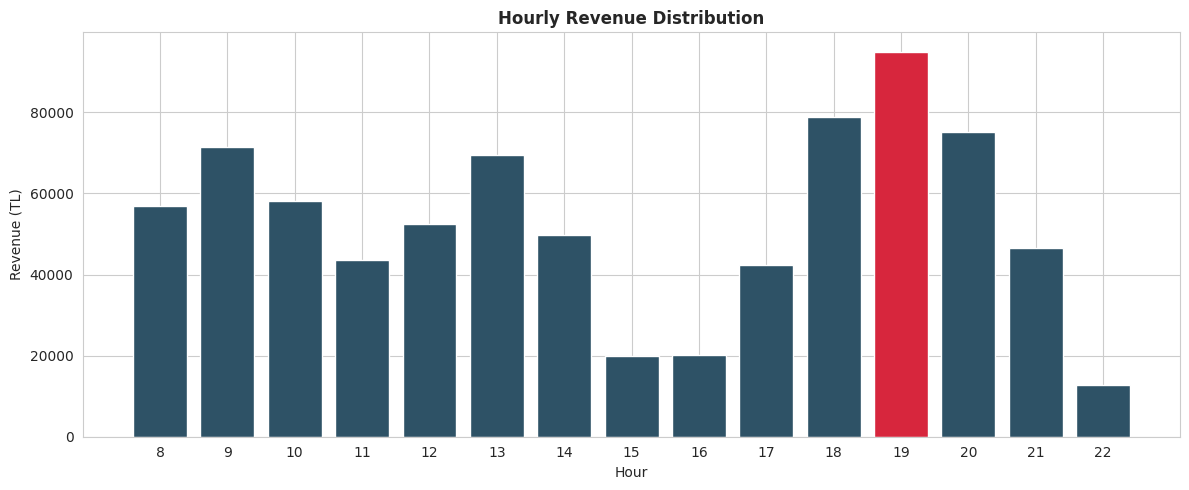

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
peak_hour = hourly.loc[hourly["revenue"].idxmax(), "hour"]
colors = [PALETTE["highlight"] if h == peak_hour else PALETTE["primary"] for h in hourly["hour"]]
ax.bar(hourly["hour"], hourly["revenue"], color=colors)
ax.set_title("Hourly Revenue Distribution", fontweight="bold")
ax.set_xlabel("Hour")
ax.set_ylabel("Revenue (TL)")
ax.set_xticks(hourly["hour"])
plt.tight_layout()
plt.show()

**Finding:** Revenue follows a bimodal pattern — a morning peak around 9:00 (coffee rush) and a stronger evening peak at 19:00. The 15:00–16:00 window is the slowest period and a candidate for targeted promotions.

## 5. Weekday vs Weekend <a id='5'></a>

In [8]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df.groupby("day_of_week").agg(
    revenue=("total", "sum"),
    transactions=("transaction_id", "count"),
    avg_basket=("total", "mean"),
).reindex(order)

weekend_avg = daily.loc[["Saturday", "Sunday"], "revenue"].mean()
weekday_avg = daily.loc[order[:5], "revenue"].mean()
uplift = (weekend_avg / weekday_avg - 1) * 100

print(f"Weekday avg revenue: {weekday_avg:,.0f} TL")
print(f"Weekend avg revenue: {weekend_avg:,.0f} TL")
print(f"Weekend uplift     : {uplift:+.1f}%")

Weekday avg revenue: 102,411 TL
Weekend avg revenue: 140,268 TL
Weekend uplift     : +37.0%


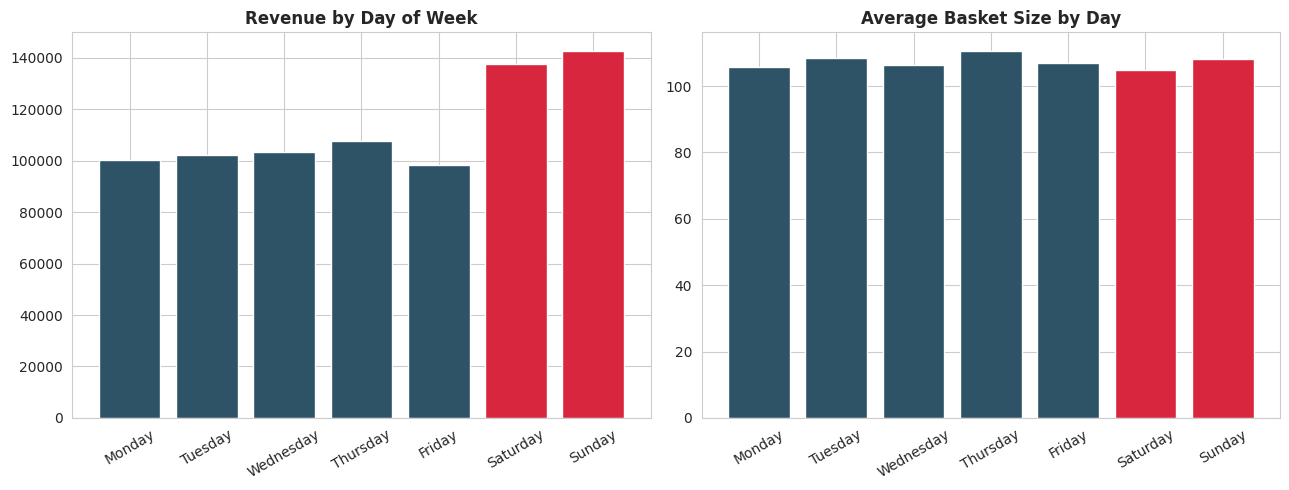

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
weekend_mask = daily.index.isin(["Saturday", "Sunday"])
colors = [PALETTE["highlight"] if w else PALETTE["primary"] for w in weekend_mask]

axes[0].bar(daily.index, daily["revenue"], color=colors)
axes[0].set_title("Revenue by Day of Week", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(daily.index, daily["avg_basket"], color=colors)
axes[1].set_title("Average Basket Size by Day", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Finding:** Weekends generate ~37% more revenue than weekdays, but the average basket size is similar — meaning weekend uplift comes from higher *foot traffic*, not bigger orders.

## 6. Hour × Day Heatmap <a id='6'></a>

A two-dimensional view that reveals when the cafe is busiest across the entire week.

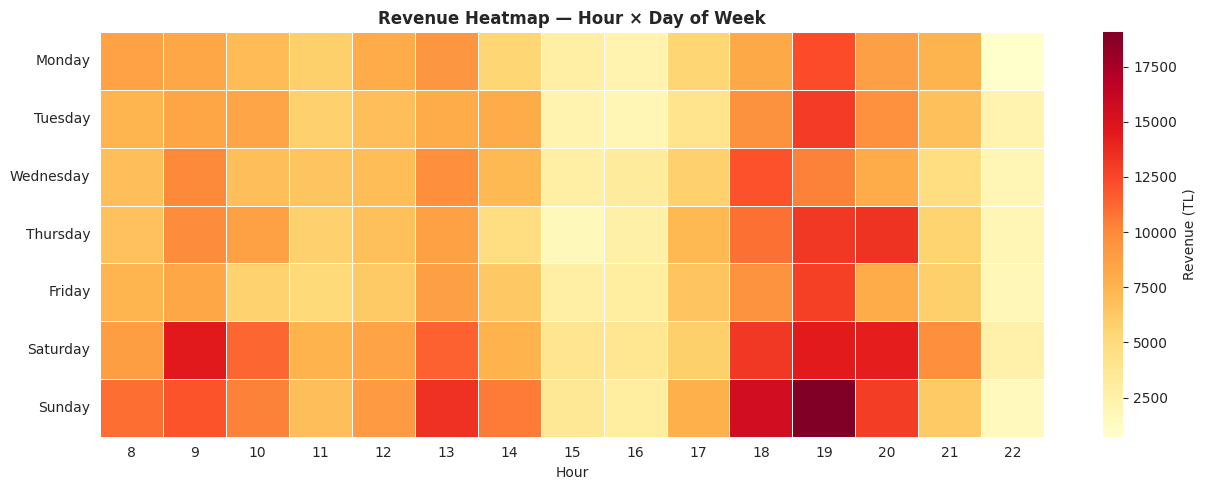

In [10]:
pivot = df.pivot_table(
    index="day_of_week", columns="hour", values="total", aggfunc="sum"
).reindex(order)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Revenue (TL)"}, ax=ax)
ax.set_title("Revenue Heatmap — Hour × Day of Week", fontweight="bold")
ax.set_xlabel("Hour")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Finding:** The hottest cells cluster around Sunday 19:00–20:00 and Saturday 9:00–10:00. These are the highest-priority hours for full staffing.

## 7. Payment Method Insights <a id='7'></a>

In [11]:
payment = df.groupby("payment_method").agg(
    revenue=("total", "sum"),
    transactions=("transaction_id", "count")
).sort_values("revenue", ascending=False)
payment["share_%"] = (payment["revenue"] / payment["revenue"].sum() * 100).round(1)
payment

,revenue,transactions,share_%
payment_method,,,
Card,499225,4616,63.0
Cash,191780,1830,24.2
Mobile,101585,946,12.8


**Finding:** Card payments account for ~63% of revenue. Cash use remains meaningful (~25%) and mobile is growing — a small cafe should support all three to avoid lost sales.

## 8. Key Findings & Recommendations <a id='8'></a>

### Findings
1. **Sandwich** is the top revenue product at 15% of total — food items outperform beverages by revenue despite lower volume.
2. **19:00** is the highest-revenue hour. Mornings (9:00) form a secondary peak.
3. **Weekends** generate **+37%** revenue vs weekdays, driven by traffic not basket size.
4. **Card** dominates payments (~63%); cash is still 25%.
5. **14:00–16:00** is the slowest window every day of the week.

### Recommendations
- 🍽️ **Stock & Staff:** Allocate more inventory of high-margin food items (Sandwich, Cheesecake) for 18:00–20:00 evening shift.
- 👥 **Scheduling:** Add at least one staff member to weekend morning and evening shifts.
- 📉 **Off-Peak Promotion:** Introduce a 14:00–16:00 happy-hour bundle (e.g. tea + dessert combo) to lift the slowest window.
- 💳 **Payments:** Maintain card + mobile support; both account for 75% of revenue.

---

*Built with Python, Pandas, Matplotlib & Seaborn.*